# Finger count NN from scratch

In [62]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import math
import matplotlib.cm as cm 
import matplotlib.pyplot as plt
import os
import functional as pyfn
from pathlib import Path

In [63]:
DATA_DIR = "/home/zhangjw/projects/ryanz/harker/NeuralNetsHK/Images/dataset-128/train"
#PNG_DIR = "/home/zhangjw/projects/ryanz/harker/NeuralNetsHK/Images/small-finger-count"
PNG_DIR = "/home/zhangjw/projects/ryanz/harker/NeuralNetsHK/Images/kaggle-finger-count/train"
DATA_DIM = 16384


In [64]:
def load_bin(fn: Path):
    finger = int(fn.name[1])
    with open(fn, 'rb') as f:
        return np.frombuffer(f.read(), dtype=np.uint8).astype(np.float32) / 255.0, finger
        

def load_png(fn: Path):
    from PIL import Image

    img = Image.open(fn)
    img_array = np.array(img).astype(np.float128) / 255.0
    finger = int(fn.stem[-2])

    return img_array, finger

def create_ds(dp: str):
    bin_files = os.listdir(dp)
    print(bin_files)

    if Path(bin_files[0]).suffix == ".bin":
        load_fun = load_bin
    else:
        load_fun = load_png
        
    tmp_data = pyfn.seq(bin_files).map(lambda fn: Path(dp) / fn).map(load_fun).to_list()

    bin_data = np.array([item[0] for item in tmp_data])
    label = np.array([item[1] for item in tmp_data])
    print(f"train label: {label}")
    print(f"finger data {label[4]} has data shape: {bin_data[4].shape}")

    return bin_data, label


['ce597643-3468-41af-9157-3a4eb10c6e1c_3L.png', '3cf7dd2e-05c3-43c2-8f8b-85fed5657766_1L.png', 'b4ebd128-70bc-41e3-86c8-0226c101077f_2R.png', '1ca6622c-dddf-4c49-828f-90683d5cdd4c_1L.png', '75a6e21f-b0b8-405d-91d4-89a157271455_1L.png', 'b079afa3-9851-4ec8-8b19-718e6dc1ba41_3L.png', 'f9de9a95-7869-4198-addb-a08371543f35_3R.png', 'd0172f73-3594-4026-b979-c6b947fe1f68_0R.png', '85625b70-62d7-498c-8e5a-022f22fc166c_4L.png', 'bd9e3b96-dfcd-4917-bf8c-73ded88cca40_5L.png', '3cf9a53c-fd15-468b-a927-79a64461a04e_3L.png', 'c74ec0f8-215b-4cd7-aca1-4cf4df435068_0L.png', '0da669d3-5bb7-4ecc-9e5c-6b63667b2441_0L.png', '39e559a5-1fc8-4d76-ba9a-93968a342856_1L.png', '6c456a49-037a-4f42-914b-044b36c8e795_3L.png', 'a7d84dae-20d7-4d33-bdce-25e5fb3f3e51_0R.png', '479619ba-feda-4921-874d-9f1961c06a7e_1L.png', 'f5cd6a06-f07a-4b26-a589-50f53e83b264_0R.png', '4d553184-21b9-405a-8572-b3b65cbdb719_4L.png', 'e3264990-9556-4db8-a503-49f8f048f454_4R.png', '2790c14c-e440-41d8-8489-b347c7f17a3c_4R.png', 'a1ac2f0b-94

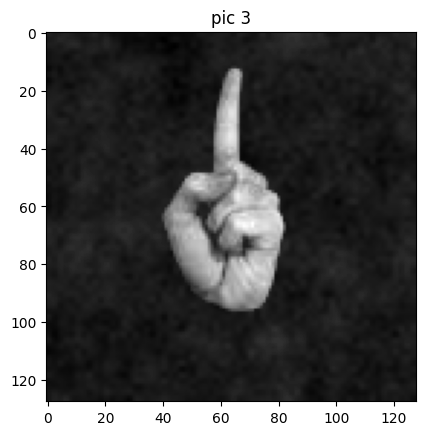

In [65]:
#bin_data, label = create_ds(DATA_DIR)
bin_data, label = create_ds(PNG_DIR)

sample_cnt = len(bin_data)
print(f"total {sample_cnt} data loaded")

index = 3
print(f"sample 4 data with label {label[index]}:\n{bin_data[index][:20]}")
plt.title(f"pic {index}")
plt.imshow(bin_data[index].reshape(128, 128), cmap='gray')

train data
occurance of  1 = 3000
occurance of  2 = 3000
occurance of  3 = 3000
occurance of  4 = 3000
occurance of  5 = 3000
y_value:
[[3000. 3000. 3000. 3000. 3000.]]


<BarContainer object of 5 artists>

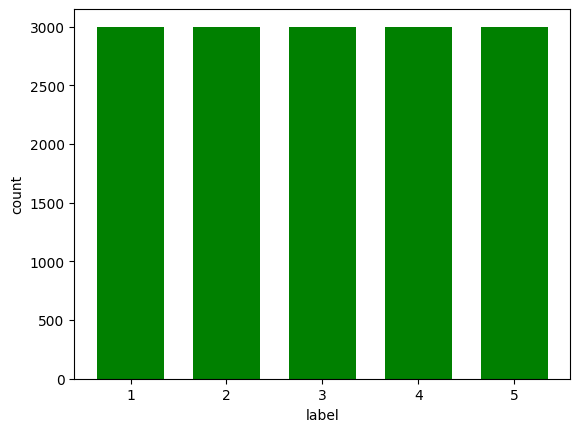

In [66]:
print("train data")
y_value = np.zeros((1, 5))
for i in range (1, 6):
    print("occurance of ", i , "=", np.count_nonzero(label==i))
    y_value[0, i-1] = np.count_nonzero(label==i)

    
print(f"y_value:\n{y_value}")

y_value=y_value.ravel()
x_value=[1,2,3,4,5]
plt.xlabel('label')
plt.ylabel('count')
plt.bar(x_value,y_value,0.7,color='g')


In [67]:
#converting train_label in one hot encoder representation 
train_data=np.reshape(bin_data,[DATA_DIM,sample_cnt])
train_label=np.zeros((5, sample_cnt))
for col in range (sample_cnt):
    val=label[col]
    for row in range (5):
        if (val==row + 1):
            train_label[val-1,col]=1
print("train_data shape="+str(np.shape(train_data)))
print("train_label shape="+str(np.shape(train_label)))
print(f"train_label:\n{train_label}")

train_data shape=(16384, 18000)
train_label shape=(5, 18000)
train_label:
[[0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 1. 0. 0.]]


In [68]:
#activation functions sigmoid relu and softmax
def sigmoid(Z):
    A = 1/(1+np.exp(-Z))
    cache = Z
    return A, cache

def relu(Z):
    A = np.maximum(0,Z)    
    cache = Z 
    return A, cache

def softmax(Z):
    e_x = np.exp(Z)
    A= e_x / np.sum(np.exp(Z))  
    cache=Z
    return A,cache   

#derivative of activation function
def relu_backward(dA, cache):
    Z = cache
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    assert (dZ.shape == Z.shape)
    return dZ

def sigmoid_backward(dA, cache):    
    Z = cache
    s = 1/(1+np.exp(-Z))
    dZ = dA * s * (1-s)
    assert (dZ.shape == Z.shape)
    return dZ

def softmax_backward(Z,cache):
    Z=cache
    length=5  
    dZ=np.zeros((sample_cnt,5))
    Z=np.transpose(Z)
    for row in range (0,sample_cnt):
            den=(np.sum(np.exp(Z[row,:])))*(np.sum(np.exp(Z[row,:])))
            for col in range (0,5):
                sums=0
                for j in range (0,5):
                    if (j!=col):
                        sums=sums+(math.exp(Z[row,j]))
                
                dZ[row,col]=(math.exp(Z[row,col])*sums)/den           
    dZ=np.transpose(dZ)
    Z=np.transpose(Z)

    assert (dZ.shape == Z.shape)
    return dZ

In [69]:
#initializing the parameters weights and bias
def initialize_parameters_deep(layer_dims):
    #np.random.seed(1)
    parameters = {}
    L = len(layer_dims)            # number of layers in the network
    
    for l in range(1, L):
        parameters['W' + str(l)] = np.random.randn(layer_dims[l], layer_dims[l-1]) / np.sqrt(layer_dims[l-1]) #*0.01
        parameters['b' + str(l)] = np.zeros((layer_dims[l], 1))
    
    return parameters

#forward propagation
def linear_forward(A, W, b):
    Z = np.dot(W,A) +b
    cache = (A, W, b)
    assert(Z.shape == (W.shape[0], A.shape[1]))
    return Z, cache

def linear_activation_forward(A_prev, W, b, activation):
    if activation == "sigmoid":
        # Inputs: "A_prev, W, b". Outputs: "A, activation_cache".
        Z, linear_cache = linear_forward(A_prev, W, b)
        A, activation_cache = sigmoid(Z)
    elif activation == "relu":
        # Inputs: "A_prev, W, b". Outputs: "A, activation_cache".
        Z, linear_cache = linear_forward(A_prev, W, b)
        #print("Z="+str(Z))
        A, activation_cache = relu(Z) 
    elif activation == "softmax":
        # Inputs: "A_prev, W, b". Outputs: "A, activation_cache".
        Z, linear_cache = linear_forward(A_prev, W, b)
        A, activation_cache = softmax(Z)
    cache = (linear_cache, activation_cache)
    return A, cache

def L_model_forward(X, parameters):
    caches = []
    A = X
    L = len(parameters) // 2                  # number of layers in the neural network
    for l in range(1, L):
        A_prev = A 
        A, cache = linear_activation_forward(A_prev, parameters['W' + str(l)], parameters['b' + str(l)], activation = "relu")
        caches.append(cache)
    AL, cache = linear_activation_forward(A, parameters['W' + str(L)], parameters['b' + str(L)], activation = "softmax")
    caches.append(cache)               
    return AL, caches

#cost function
def compute_cost(AL, Y):
    
    m = Y.shape[1]
    cost = (-1 / m) * np.sum(np.multiply(Y, np.log(AL)) + np.multiply(1 - Y, np.log(1 - AL)))
    #print("cost="+str(cost))
    return cost

#backward propagation
def linear_backward(dZ, cache):
    A_prev, W, b = cache
    m = A_prev.shape[1]
    dW = 1./m * np.dot(dZ,A_prev.T)  
    db = (1/m)*np.sum(dZ, axis=1, keepdims=True);
    dA_prev = np.dot(W.T,dZ)
    return dA_prev, dW, db

def linear_activation_backward(dA, cache, activation):
    linear_cache, activation_cache = cache
    if activation == "relu":
        dZ = relu_backward(dA, activation_cache)
        dA_prev, dW, db = linear_backward(dZ, linear_cache)  
    elif activation == "sigmoid":
        dZ = sigmoid_backward(dA, activation_cache)
        dA_prev, dW, db = linear_backward(dZ, linear_cache)
    elif activation == "softmax":
        dZ = softmax_backward(dA, activation_cache)
        dA_prev, dW, db = linear_backward(dZ, linear_cache)
    return dA_prev, dW, db

def L_model_backward(AL, Y, caches):
    grads = {}
    L = len(caches) # the number of layers
    dAL = - (np.divide(Y, AL) - np.divide(1 - Y, 1 - AL))
    M=len(layers_dims)
    current_cache = caches[M-2]
    grads["dA"+str(M-1)], grads["dW"+str(M-1)], grads["db"+str(M-1)] = linear_activation_backward(dAL, current_cache, activation = "softmax")#M-1
    for l in reversed(range(L-1)):
        current_cache = caches[l]
        dA_prev_temp, dW_temp, db_temp = linear_activation_backward(grads["dA" + str(l + 2)], current_cache, activation = "relu")
        grads["dA" + str(l + 1)] = dA_prev_temp
        grads["dW" + str(l + 1)] = dW_temp
        grads["db" + str(l + 1)] = db_temp
    
    return grads

#upgrade function for weights and bias
def update_parameters(parameters, grads, learning_rate):
    for l in range(len_update-1):
        parameters["W" + str(l+1)] =parameters["W" + str(l+1)] - (learning_rate*grads["dW" + str(l+1)])
        parameters["b" + str(l+1)] = parameters["b" + str(l+1)] - (learning_rate*grads["db" + str(l+1)])
    return parameters

def plot_graph(cost_plot):
       
    x_value=list(range(1,len(cost_plot)+1))
    #print(x_value)
    #print(cost_plot)
    plt.xlabel('iteration')
    plt.ylabel('cost')
    plt.plot(x_value,cost_plot,0.,color='g')

In [70]:
#defining structure of neural network
layers_dims = [DATA_DIM,500,400,300,100,5] #  n-layer model (n=6 including input and output layer)
len_update=len(layers_dims)



In [71]:
#function to call sub_functions
def L_layer_model(X, Y, layers_dims, learning_rate , num_iterations , print_cost=False):#lr was 0.009
    print("training...")
    costs = []  
    cost_plot=np.zeros(num_iterations)
    parameters = initialize_parameters_deep(layers_dims)
    for i in range(0, num_iterations):
        AL, caches = L_model_forward(X, parameters)
        cost =compute_cost(AL, Y)
        grads = L_model_backward(AL, Y, caches)
        parameters = update_parameters(parameters, grads, learning_rate) 
        cost_plot[i]=cost;
    
    plot_graph(cost_plot)
    return parameters

In [73]:
num_iter = 35
l_rate = 0.0001

#variable parameter in network learning_rate, iterationd 
parameters = L_layer_model(train_data, train_label, layers_dims,learning_rate = l_rate, num_iterations =num_iter , print_cost = True) 
print("training done")

training...


/tmp/ipykernel_11995/3124270698.py:13: RuntimeWarning: overflow encountered in exp
  e_x = np.exp(Z)
/tmp/ipykernel_11995/3124270698.py:14: RuntimeWarning: overflow encountered in exp
  A= e_x / np.sum(np.exp(Z))
/tmp/ipykernel_11995/3124270698.py:14: RuntimeWarning: invalid value encountered in divide
  A= e_x / np.sum(np.exp(Z))
/tmp/ipykernel_11995/4076710743.py:53: RuntimeWarning: divide by zero encountered in log
  cost = (-1 / m) * np.sum(np.multiply(Y, np.log(AL)) + np.multiply(1 - Y, np.log(1 - AL)))
/tmp/ipykernel_11995/4076710743.py:53: RuntimeWarning: invalid value encountered in multiply
  cost = (-1 / m) * np.sum(np.multiply(Y, np.log(AL)) + np.multiply(1 - Y, np.log(1 - AL)))
/tmp/ipykernel_11995/4076710743.py:82: RuntimeWarning: divide by zero encountered in divide
  dAL = - (np.divide(Y, AL) - np.divide(1 - Y, 1 - AL))
/tmp/ipykernel_11995/4076710743.py:82: RuntimeWarning: invalid value encountered in divide
  dAL = - (np.divide(Y, AL) - np.divide(1 - Y, 1 - AL))
/tmp/i

OverflowError: math range error